# 1. Setup

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
from adjustText import adjust_text

# Set style for better plots
sns.set(style="whitegrid", palette="colorblind", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Scaling Laws
# 2.1 Data Preparation

In [3]:
import glob
import os
import re

# Find all out-shakespeare-*** directories
logs_dir = 'logs'
out_dirs = sorted(glob.glob(os.path.join(logs_dir, 'out-shakespeare-*')))

# Parse the directory names and train.out files
data = []
for out_dir in out_dirs:
    dir_name = os.path.basename(out_dir)
    # Extract parameters from directory name: out-shakespeare-{n_layer}-{n_embd}-{dataset_size}
    match = re.match(r'out-shakespeare-(\d+)-(\d+)-([\d.]+)', dir_name)
    if not match:
        continue
    
    n_layer, n_embd, dataset_size = match.groups()
    train_file = os.path.join(out_dir, 'train.out')
    
    if not os.path.exists(train_file):
        continue
    
    # Parse train.out to extract training info
    val_losses = []
    train_losses = []
    num_parameters = None
    tokens_per_iteration = None
    max_iters = None
    
    with open(train_file, 'r') as f:
        for line in f:
            # Parse number of parameters
            if 'number of parameters:' in line:
                match = re.search(r'number of parameters: (\d+)', line)
                if match:
                    num_parameters = int(match.group(1))
            
            # Parse tokens per iteration
            if 'tokens per iteration will be:' in line:
                match = re.search(r'tokens per iteration will be: ([\d,]+)', line)
                if match:
                    tokens_per_iteration = int(match.group(1).replace(',', ''))
            
            # Parse max_iters
            if 'max_iters = ' in line:
                match = re.search(r'max_iters = ([\d.]+)', line)
                if match:
                    max_iters = float(match.group(1))
            
            # Parse validation and training losses
            match = re.search(r'step \d+: train loss ([\d.]+), val loss ([\d.]+)', line)
            if match:
                train_loss = float(match.group(1))
                val_loss = float(match.group(2))
                train_losses.append(train_loss)
                val_losses.append(val_loss)
    
    if val_losses and num_parameters and tokens_per_iteration and max_iters:
        # Calculate FLOPs: 6 * num_parameters * total_tokens
        # (6 accounts for forward, backward, and parameter updates)
        total_tokens = tokens_per_iteration * int(max_iters)
        flops = 6 * num_parameters * total_tokens
        
        # Use final validation loss
        final_val_loss = val_losses[-1]
        final_train_loss = train_losses[-1]
        
        data.append({
            'dir_name': dir_name,
            'model_size': f'{n_layer}L-{n_embd}E',
            'dataset_size': float(dataset_size),
            'val_loss': final_val_loss,
            'train_loss': final_train_loss,
            'n_layer': int(n_layer),
            'n_embd': int(n_embd),
            'num_parameters': num_parameters,
            'tokens_per_iteration': tokens_per_iteration,
            'max_iters': int(max_iters),
            'total_tokens': total_tokens,
            'flops': flops,
        })

df_scaling = pd.DataFrame(data)
print(f"Loaded {len(df_scaling)} configurations from {logs_dir}")
print(df_scaling[['model_size', 'dataset_size', 'val_loss', 'train_loss', 'num_parameters', 'flops']].to_string())

Loaded 16 configurations from logs
   model_size  dataset_size  val_loss  train_loss  num_parameters              flops
0     2L-128E         0.125    2.7019      2.5854          434944      6242483306496
1     2L-128E         0.250    2.6752      2.6106          434944      6242483306496
2     2L-128E         0.500    2.6678      2.6501          434944      6242483306496
3     2L-128E         1.000    2.6530      2.6490          434944      6242483306496
4     4L-256E         0.125    2.3338      1.0412         3230208   1252387096363008
5     4L-256E         0.250    2.0584      1.2847         3230208   1252387096363008
6     4L-256E         0.500    1.9226      1.3901         3230208   1252387096363008
7     4L-256E         1.000    1.6790      1.4760         3230208   1252387096363008
8     5L-320E         0.125    4.3452      0.0772         6250240   4688052014284800
9     5L-320E         0.250    2.7656      0.3602         6250240   4688052014284800
10    5L-320E         0.500   

# 2.2 Loss Grid Table

In [4]:
pivot_val_loss = df_scaling.pivot(index="model_size", columns="dataset_size", values="val_loss")
print("Validation Loss Grid:")
display(pivot_val_loss)

Validation Loss Grid:


dataset_size,0.125,0.250,0.500,1.000
model_size,,,,
2L-128E,2.7019,2.6752,2.6678,2.6530
4L-256E,2.3338,2.0584,1.9226,1.6790
5L-320E,4.3452,2.7656,1.9719,1.4380
6L-384E,5.8046,4.8298,3.3084,1.7517


# 2.3 Scaling Plots

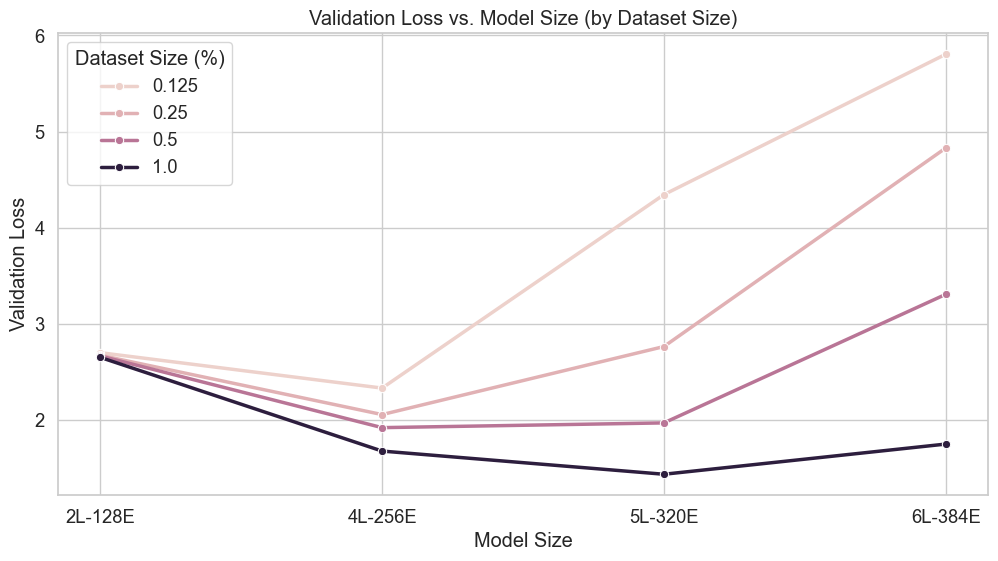

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_scaling, x="model_size", y="val_loss", hue="dataset_size", marker="o", linewidth=2.5)
plt.title("Validation Loss vs. Model Size (by Dataset Size)")
plt.ylabel("Validation Loss")
plt.xlabel("Model Size")
plt.grid(True)
plt.legend(title="Dataset Size (%)")
plt.show()



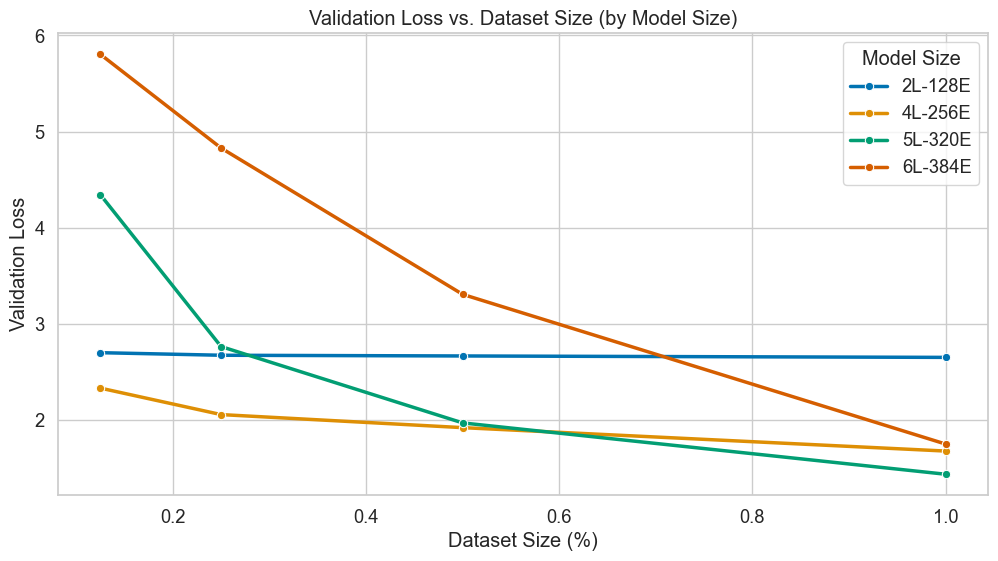

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_scaling, x="dataset_size", y="val_loss", hue="model_size", marker="o", linewidth=2.5)
plt.title("Validation Loss vs. Dataset Size (by Model Size)")
plt.ylabel("Validation Loss")
plt.xlabel("Dataset Size (%)")
plt.grid(True)
plt.legend(title="Model Size")
plt.show()



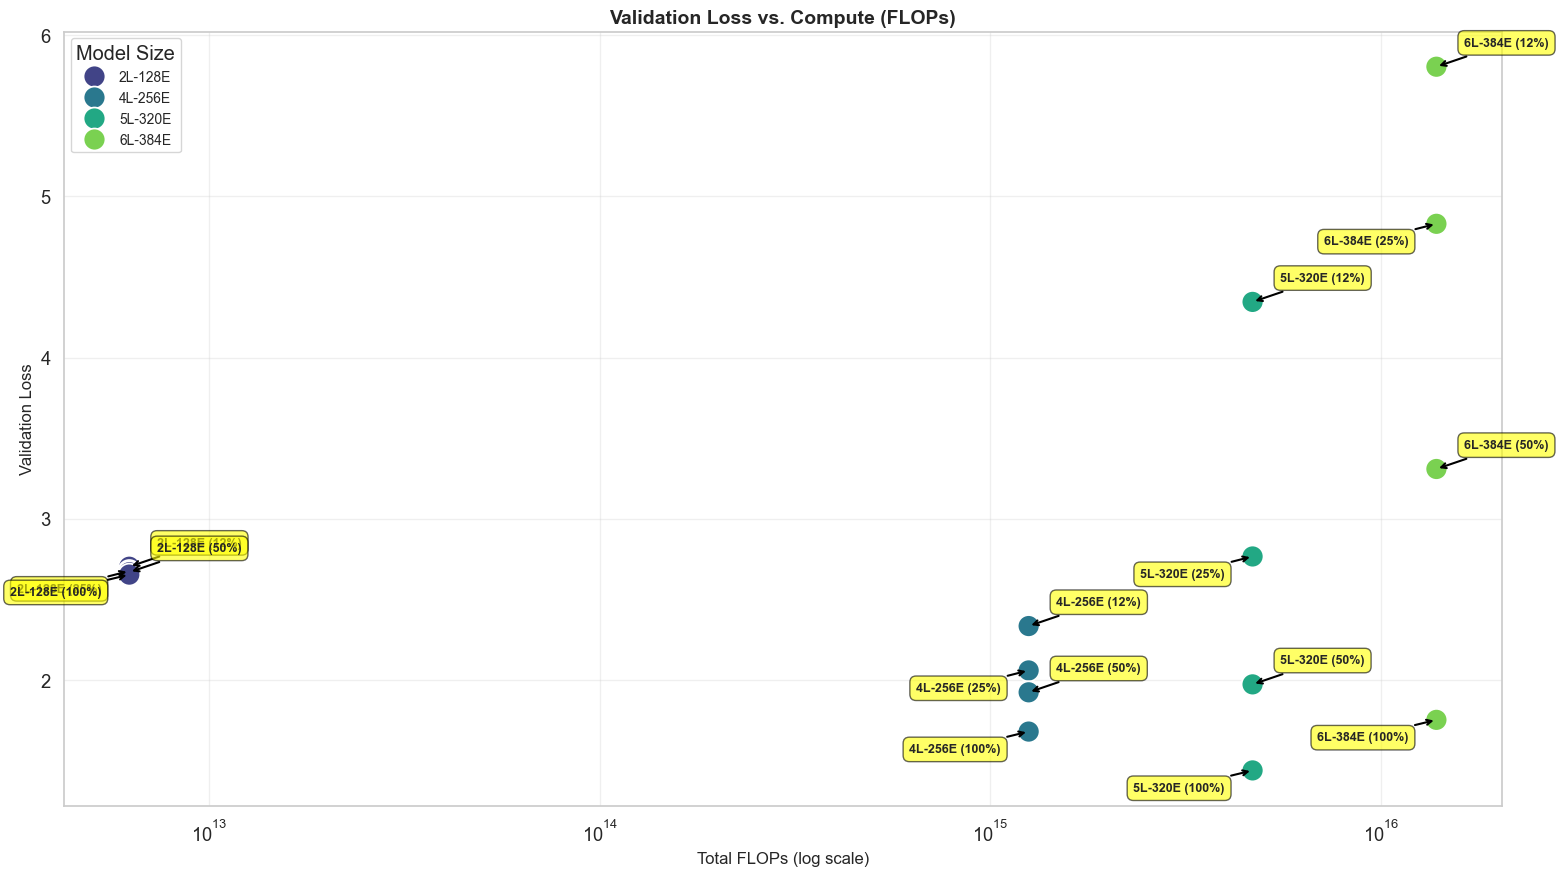

In [9]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df_scaling, x="flops", y="val_loss", hue="model_size", s=250, palette="viridis")

# Add labels with arrows pointing to each point
for idx, row in df_scaling.iterrows():
    label = f"{row['model_size']} ({(row['dataset_size']*100):.0f}%)"
    
    # Alternate label positions to reduce overlaps
    if idx % 2 == 0:
        offset = (20, 15)
        ha = 'left'
    else:
        offset = (-20, -15)
        ha = 'right'
    
    plt.annotate(label, 
                xy=(row['flops'], row['val_loss']),
                xytext=offset, 
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                ha=ha,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.6, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5, connectionstyle='arc3,rad=0'))

plt.xscale('log')
plt.title("Validation Loss vs. Compute (FLOPs)", fontsize=14, fontweight='bold')
plt.ylabel("Validation Loss", fontsize=12)
plt.xlabel("Total FLOPs (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Model Size", loc='best', fontsize=10)
plt.tight_layout()
plt.show()


# 2.4 Compute-Optimal Frontier


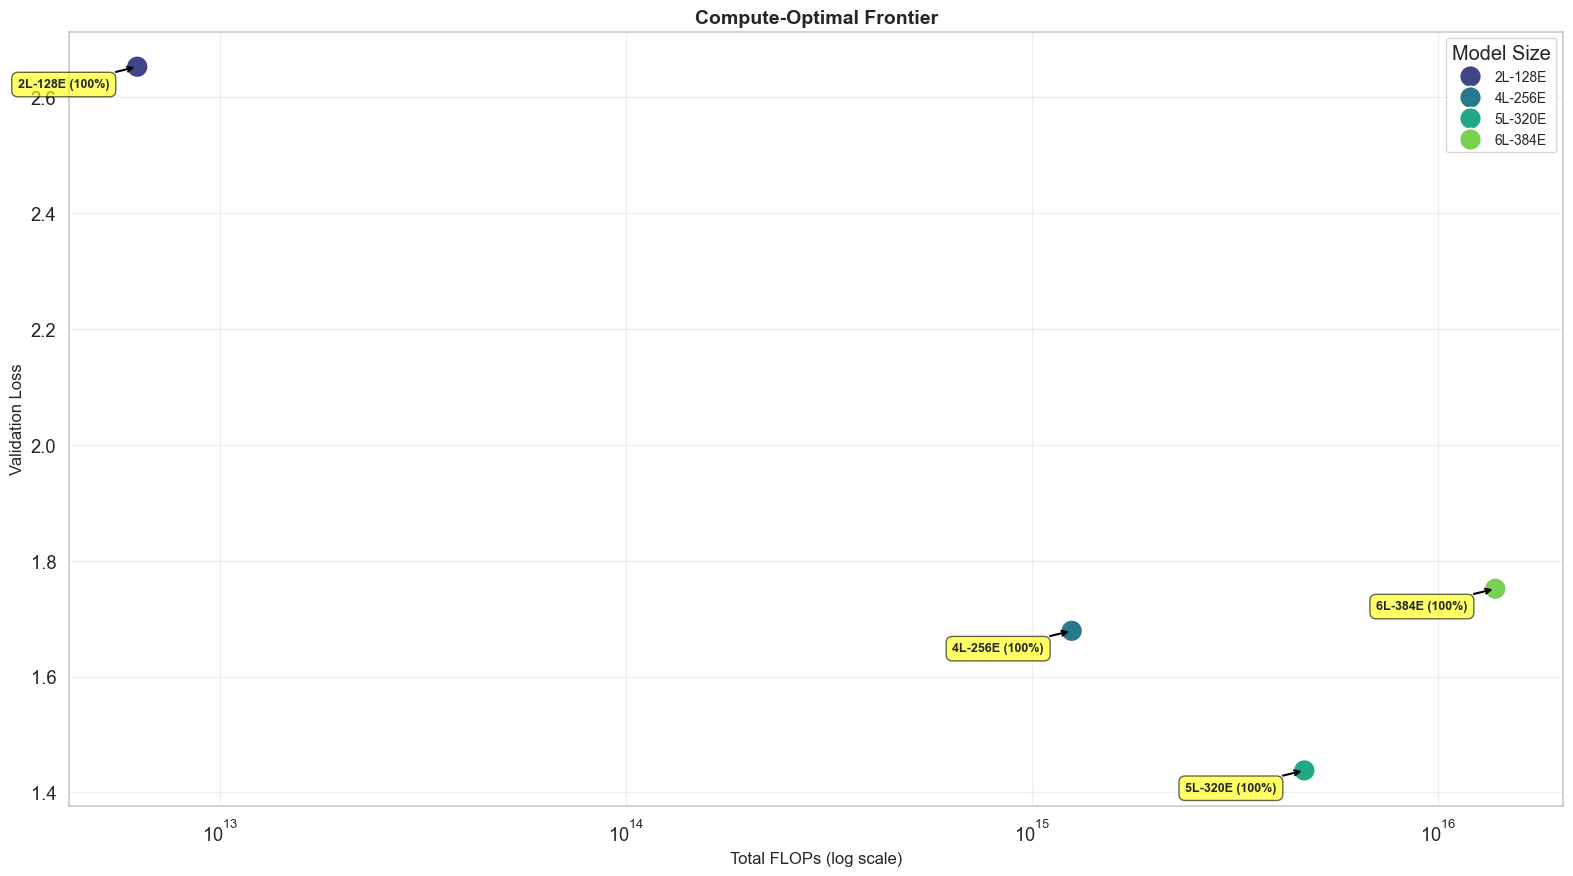

In [12]:
optimal = df_scaling.loc[df_scaling.groupby('flops')['val_loss'].idxmin()]
plt.figure(figsize=(16, 9))
sns.scatterplot(data=optimal, x="flops", y="val_loss", hue="model_size", s=250, palette="viridis")

# Add labels with arrows pointing to each point
for idx, row in optimal.iterrows():
    label = f"{row['model_size']} ({(row['dataset_size']*100):.0f}%)"
    
    # Alternate label positions to reduce overlaps
    if idx % 2 == 0:
        offset = (20, 15)
        ha = 'left'
    else:
        offset = (-20, -15)
        ha = 'right'
    
    plt.annotate(label, 
                xy=(row['flops'], row['val_loss']),
                xytext=offset, 
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                ha=ha,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.6, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5, connectionstyle='arc3,rad=0'))

plt.xscale('log')
plt.title("Compute-Optimal Frontier", fontsize=14, fontweight='bold')
plt.ylabel("Validation Loss", fontsize=12)
plt.xlabel("Total FLOPs (log scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Model Size", loc='best', fontsize=10)
plt.tight_layout()
plt.show()
